<a href="https://colab.research.google.com/github/Dinidu-Lochana/ASP.Net-CRUD/blob/main/Cat_and_Dog_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install numpy -q
!pip install pandas -q
!pip install matplotlib -q
!pip install tensorflow -q

!pip install opendatasets -q

# **Importing Libraries**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import opendatasets as od

In [4]:
od.download("https://www.kaggle.com/datasets/tongpython/cat-and-dog")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: dinidulochana
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog


100%|██████████| 218M/218M [00:01<00:00, 192MB/s]


In [41]:
Batch_size = 32
Image_size = (128,128)

In [42]:
train_data_dir = "/content/cat-and-dog/training_set/training_set"
test_data_dir = "/content/cat-and-dog/test_set/test_set"

In [43]:
train_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                       image_size = Image_size,
                                                       batch_size = Batch_size,
                                                       subset = 'training',
                                                       validation_split = 0.1,
                                                       seed = 42)

validation_data = tf.keras.utils.image_dataset_from_directory(train_data_dir,
                                                       image_size = Image_size,
                                                       batch_size = Batch_size,
                                                       subset = 'validation',
                                                       validation_split = 0.1,
                                                       seed = 42)

Found 8005 files belonging to 2 classes.
Using 7205 files for training.
Found 8005 files belonging to 2 classes.
Using 800 files for validation.


In [44]:
test_data = tf.keras.utils.image_dataset_from_directory(test_data_dir,
                                                       image_size = Image_size,
                                                       batch_size = Batch_size)

Found 2023 files belonging to 2 classes.


# **Dataset Description**

In [45]:
class_names = train_data.class_names
class_names

['cats', 'dogs']

In [11]:
for image_batch,label_batch in train_data.take(1):
  print(image_batch.shape)
  print(label_batch.shape)

(32, 128, 128, 3)
(32,)


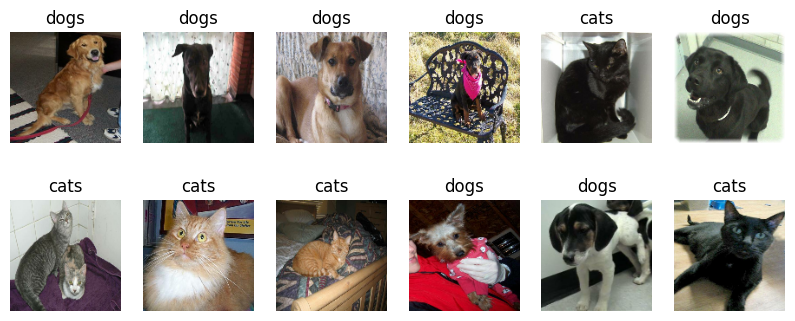

In [12]:
plt.figure(figsize=(10,4))
for image,label in train_data.take(1):
  for i in range(12):
    ax = plt.subplot(2,6,i+1)
    plt.imshow(image[i].numpy().astype("uint8"))
    plt.title(class_names[label[i]])
    plt.axis("off")

# **Data Preprocessing**

In [13]:
for image,label in train_data.take(1):
  for i in range(1):
    print(image)

tf.Tensor(
[[[[227.95229   235.95229   248.91356  ]
   [230.13911   238.13911   249.13911  ]
   [221.26953   230.26953   239.26953  ]
   ...
   [214.03568   221.21146   228.09036  ]
   [203.23047   212.67969   226.33203  ]
   [217.91696   227.36618   240.96043  ]]

  [[213.65524   221.65524   234.65524  ]
   [210.        218.        229.       ]
   [212.61606   221.61606   230.61606  ]
   ...
   [210.92683   217.92683   225.92683  ]
   [186.36177   195.36177   203.66646  ]
   [191.98476   200.98476   209.28944  ]]

  [[213.        221.        234.       ]
   [213.        221.        232.       ]
   [213.        222.        231.       ]
   ...
   [163.92838   168.32594   179.39626  ]
   [161.15009   167.4118    176.15009  ]
   [149.52092   155.78264   164.52092  ]]

  ...

  [[115.046036  118.53822    87.78432  ]
   [176.96849   180.99445   148.0204   ]
   [143.98785   145.53893   107.2231   ]
   ...
   [141.9365    155.22469   101.09274  ]
   [127.72743   129.8329     82.8329   ]
   [1

In [14]:
train_data = train_data.map(lambda x,y : (x/255,y))
validation_data = validation_data.map(lambda x,y : (x/255,y))
test_data = test_data.map(lambda x,y : (x/255,y))

In [15]:
for image,label in train_data.take(1):
  for i in range(1):
    print(image)

tf.Tensor(
[[[[0.33503622 0.36991674 0.36723596]
   [0.42458174 0.45595428 0.46379742]
   [0.4147875  0.44409204 0.46206078]
   ...
   [0.33555454 0.07814786 0.1428206 ]
   [0.35196546 0.10472747 0.1713313 ]
   [0.34928566 0.11754546 0.18804178]]

  [[0.38340682 0.41828734 0.41560656]
   [0.39786005 0.4292326  0.43707573]
   [0.401447   0.43075153 0.4487203 ]
   ...
   [0.28808916 0.10912188 0.1871472 ]
   [0.3059836  0.14978087 0.22997855]
   [0.2577681  0.13990659 0.2105239 ]]

  [[0.37206912 0.40694964 0.40426886]
   [0.42226574 0.4536383  0.46148142]
   [0.38286552 0.41217005 0.4301388 ]
   ...
   [0.09459683 0.03303127 0.12276779]
   [0.18588915 0.1475848  0.24141164]
   [0.42293176 0.42452487 0.50729144]]

  ...

  [[0.14467163 0.18047377 0.17100686]
   [0.19738734 0.23625094 0.21755467]
   [0.19790219 0.23161574 0.20366473]
   ...
   [0.11177057 0.31365752 0.34909502]
   [0.17935851 0.40862486 0.37733644]
   [0.22516347 0.37726715 0.33587372]]

  [[0.24286464 0.30265322 0.377881

In [16]:
# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical", input_shape=(128, 128, 3)),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
model = tf.keras.Sequential()

model.add(data_augmentation)

# Convolutional layers
model.add(tf.keras.layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Conv2D(256, kernel_size=3, padding='same', activation='relu'))
model.add(tf.keras.layers.MaxPooling2D())

model.add(tf.keras.layers.Dropout(0.3))

# Flatten and dense layers
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(512, activation='relu'))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.Dense(256, activation='relu'))
model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [22]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 32, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 65536)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │      33,554,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 34,059,393 (129.93 MB)

 Trainable params: 34,058,369 (129.92 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [23]:
model.compile(optimizer=tf.keras.optimizers.Adam(),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy'])

In [24]:
history = model.fit(train_data,
                    epochs=50,
                    validation_data=validation_data)

Epoch 1/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.5134 - loss: 0.7790 - val_accuracy: 0.5300 - val_loss: 0.7828
Epoch 2/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 82ms/step - accuracy: 0.5533 - loss: 0.7262 - val_accuracy: 0.5088 - val_loss: 1.2044
Epoch 3/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.5542 - loss: 0.7052 - val_accuracy: 0.5125 - val_loss: 0.9905
Epoch 4/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - accuracy: 0.6020 - loss: 0.6656 - val_accuracy: 0.5950 - val_loss: 0.6913
Epoch 5/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 21s 81ms/step - accuracy: 0.6185 - loss: 0.6443 - val_accuracy: 0.6500 - val_loss: 0.6373
Epoch 6/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 20s 80ms/step - accuracy: 0.6340 - loss: 0.6369 - val_accuracy: 0.6025 - val_loss: 0.7009
Epoch 7/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 21s 82ms/step - accuracy: 0.6526 - loss: 0.6263 - val_accuracy: 0.6413 - val_loss: 0.6203
Epoch 8/50
226/226 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - accuracy: 0.6547 - loss: 0.6207 - 

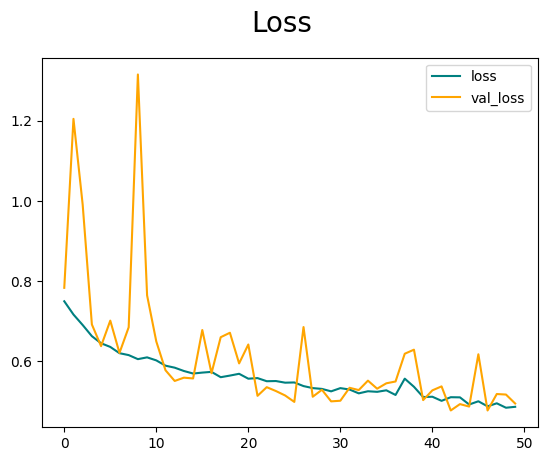

In [25]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend()
plt.show()


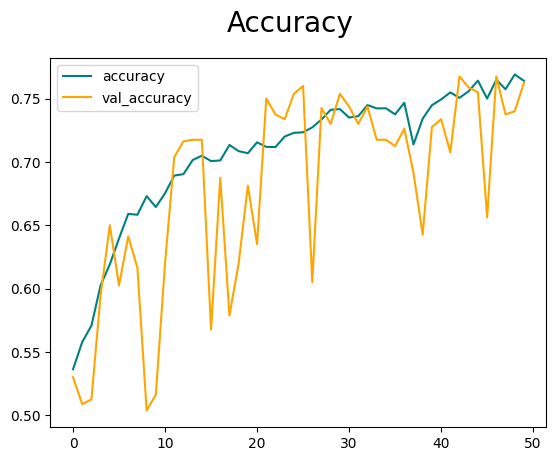

In [26]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend()
plt.show()

# **Model Evaluation**

In [27]:
precision = tf.keras.metrics.Precision()
recall = tf.keras.metrics.Recall()
accuracy = tf.keras.metrics.BinaryAccuracy()

In [28]:
for batch in test_data.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    precision.update_state(y, yhat)
    recall.update_state(y, yhat)
    accuracy.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━

In [29]:
precision.result().numpy(), recall.result().numpy(), accuracy.result().numpy()

(0.7533461, 0.7786561, 0.76173997)

In [30]:
!pip install opencv-python

In [31]:
import cv2

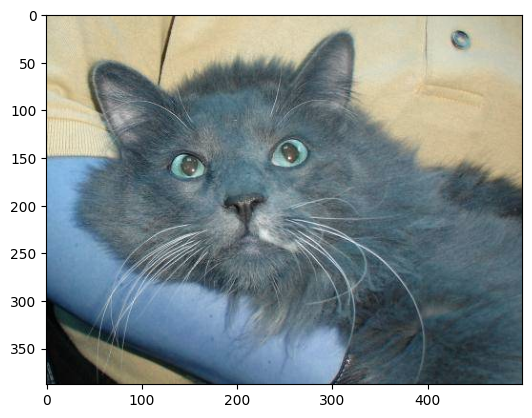

In [63]:
image = cv2.imread('/content/cat-and-dog/test_set/test_set/cats/cat.4330.jpg')
plt.imshow(image)
plt.show()

In [64]:
resized_image = tf.image.resize(image, Image_size)
scaled_image = resized_image/255

In [65]:
scaled_image

<tf.Tensor: shape=(128, 128, 3), dtype=float32, numpy=
array([[[0.805509  , 0.78197956, 0.6682541 ],
        [0.8158701 , 0.7923407 , 0.6786152 ],
        [0.8185336 , 0.7950042 , 0.6812787 ],
        ...,
        [0.6981005 , 0.6745711 , 0.5608456 ],
        [0.69411767, 0.67058825, 0.5568628 ],
        [0.7060049 , 0.6550245 , 0.52953434]],

       [[0.79368395, 0.77015454, 0.65642905],
        [0.81930625, 0.79577684, 0.68205136],
        [0.813039  , 0.7895096 , 0.6757841 ],
        ...,
        [0.71395814, 0.69042873, 0.57670325],
        [0.6981053 , 0.67457587, 0.5608504 ],
        [0.7021446 , 0.6590074 , 0.5413603 ]],

       [[0.7872099 , 0.7636805 , 0.649955  ],
        [0.81506205, 0.79153264, 0.67780715],
        [0.8306583 , 0.8071289 , 0.6934034 ],
        ...,
        [0.7226103 , 0.6990809 , 0.5853554 ],
        [0.7002451 , 0.6767157 , 0.5629902 ],
        [0.71341914, 0.6702819 , 0.5604779 ]],

       ...,

       [[0.20570332, 0.25919595, 0.27273762],
        [0.27

In [66]:
np.expand_dims(scaled_image,0).shape

(1, 128, 128, 3)

In [67]:
y_hat = model.predict(np.expand_dims(scaled_image,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [68]:
y_hat

array([[0.10934963]], dtype=float32)

In [69]:
class_names

['cats', 'dogs']

In [70]:
if y_hat > 0.5:
    print(f'Predicted class is Dog')
else:
    print(f'Predicted class is Cat')

Predicted class is Cat
